In [2]:
import pandas as pd
import geopandas as gpd
import numpy as np
import os
from dotenv import load_dotenv
load_dotenv()

DATA_LOC = os.getenv("DATA_LOC")
print(DATA_LOC)

~/Data/DCIA_DATA/Data/


In [5]:
gdf = gpd.read_file(DATA_LOC + "GENERAL SOURCES/WijkBuurtkaart_2025_v1/wijkenbuurten_2025_v1.gpkg", layer="buurten")
gdf.head()

/opt/anaconda3/envs/heijmans/lib/python3.11/site-packages/pyogrio/geopandas.py:265: UserWarning: More than one layer found in 'wijkenbuurten_2025_v1.gpkg': 'buurten' (default), 'gemeenten', 'wijken'. Specify layer parameter to avoid this warning.
  result = read_func(


,buurtcode,buurtnaam,wijkcode,gemeentecode,gemeentenaam,indelingswijziging_wijken_en_buurten,water,meest_voorkomende_postcode,dekkingspercentage,omgevingsadressendichtheid,...,perc_geb_in_nl_met_herkomstland_in_europa_ex_nl,perc_geb_in_nl_met_herkomstland_buiten_europa,perc_geb_buiten_nl_met_herkomstlnd_in_europa_ex_nl,perc_geb_buiten_nl_met_herkomstlnd_buiten_europa,oppervlakte_totaal_in_ha,oppervlakte_land_in_ha,oppervlakte_water_in_ha,jrstatcode,jaar,geometry
0,BU09989999,Buitenland,WK099899,GM0998,Buitenland,-99997,B,-99997,-99997,-99997,...,-99997,-99997,-99997,-99997,-99997,-99997,-99997,2025BU09989999,2025,"MULTIPOLYGON (((123629.78 379674.57, 123627.21..."
1,BU00349997,Groot binnenwater,WK003499,GM0034,Almere,-99997,JA,-99997,-99997,-99997,...,-99997,-99997,-99997,-99997,-99997,-99997,-99997,2025BU00349997,2025,"MULTIPOLYGON (((150087.299 479382.379, 150000...."
2,BU00509997,Groot binnenwater,WK005099,GM0050,Zeewolde,-99997,JA,-99997,-99997,-99997,...,-99997,-99997,-99997,-99997,-99997,-99997,-99997,2025BU00509997,2025,"MULTIPOLYGON (((155047.32 474836.246, 155049.0..."
3,BU00609998,Buitenwater,WK006099,GM0060,Ameland,-99997,JA,-99997,-99997,-99997,...,-99997,-99997,-99997,-99997,-99997,-99997,-99997,2025BU00609998,2025,"MULTIPOLYGON (((196000 608000, 195250 607500, ..."
4,BU00729998,Buitenwater,WK007299,GM0072,Harlingen,-99997,JA,-99997,-99997,-99997,...,-99997,-99997,-99997,-99997,-99997,-99997,-99997,2025BU00729998,2025,"MULTIPOLYGON (((158000 581000, 158331.38 58046..."


3 layers available:
- buurten: neighbourhood (smallest level)
- gemeenten: muniicpality
- wijken: district

### Gemeenten

We have multypoligons of 424 municpalities. We have data only from 2025

Indicators are:
- gemeentecode: municipality code
- gemeentenaam: municipality name
- indelingswijziging_wijken_en_buurten: change in district and neighborhood classification
- water: water area indicator
- omgevingsadressendichtheid: surrounding address density
- stedelijkheid_adressen_per_km2: urbanization level addresses per km²
- bevolkingsdichtheid_inwoners_per_km2: population density inhabitants per km²
- aantal_inwoners: number of inhabitants
- mannen: men
- vrouwen: women
- percentage_personen_0_tot_15_jaar: percentage persons aged 0 to 15 years
- percentage_personen_15_tot_25_jaar: percentage persons aged 15 to 25 years
- percentage_personen_25_tot_45_jaar: percentage persons aged 25 to 45 years
- percentage_personen_45_tot_65_jaar: percentage persons aged 45 to 65 years
- percentage_personen_65_jaar_en_ouder: percentage persons aged 65 and older
- percentage_ongehuwd: percentage unmarried
- percentage_gehuwd: percentage married
- percentage_gescheid: percentage divorced
- percentage_verweduwd: percentage widowed
- aantal_huishoudens: number of households
- percentage_eenpersoonshuishoudens: percentage single person households
- percentage_huishoudens_zonder_kinderen: percentage households without children
- percentage_huishoudens_met_kinderen: percentage households with children
- gemiddelde_huishoudsgrootte: average household size
- percentage_met_herkomstland_nederland: percentage with country of origin Netherlands
- percentage_met_herkomstland_uit_europa_excl_nl: percentage with country of origin in Europe excluding Netherlands
- percentage_met_herkomstland_buiten_europa: percentage with country of origin outside Europe
- percentage_geb_in_nl_met_herkomstland_nederland: percentage born in Netherlands with origin Netherlands
- perc_geb_in_nl_met_herkomstland_in_europa_ex_nl: percentage born in Netherlands with origin in Europe excluding Netherlands
- perc_geb_in_nl_met_herkomstland_buiten_europa: percentage born in Netherlands with origin outside Europe
- perc_geb_buiten_nl_met_herkomstlnd_in_europa_ex_nl: percentage born outside Netherlands with origin in Europe excluding Netherlands
- perc_geb_buiten_nl_met_herkomstlnd_buiten_europa: percentage born outside Netherlands with origin outside Europe
- oppervlakte_totaal_in_ha: total area in hectares
- oppervlakte_land_in_ha: land area in hectares
- oppervlakte_water_in_ha: water area in hectares
- jrstatcode: statistical year code
- jaar: year
- geometry: geometry (spatial shape)

In [20]:
gementeen = gpd.read_file(DATA_LOC + "GENERAL SOURCES/WijkBuurtkaart_2025_v1/wijkenbuurten_2025_v1.gpkg", layer="gemeenten")
print(gementeen.shape)
print(gementeen["jaar"].unique())

gementeen= gementeen.replace([-99999, -99998, -99997, -99996], np.nan) #Replacing weird numbers with NA
gementeen.tail()

(424, 38)
<StringArray>
['2025']
Length: 1, dtype: str


,gemeentecode,gemeentenaam,indelingswijziging_wijken_en_buurten,water,omgevingsadressendichtheid,stedelijkheid_adressen_per_km2,bevolkingsdichtheid_inwoners_per_km2,aantal_inwoners,mannen,vrouwen,...,perc_geb_in_nl_met_herkomstland_in_europa_ex_nl,perc_geb_in_nl_met_herkomstland_buiten_europa,perc_geb_buiten_nl_met_herkomstlnd_in_europa_ex_nl,perc_geb_buiten_nl_met_herkomstlnd_buiten_europa,oppervlakte_totaal_in_ha,oppervlakte_land_in_ha,oppervlakte_water_in_ha,jrstatcode,jaar,geometry
419,GM1979,Eemsdelta,1.0,NEE,707.0,4.0,167.0,44795.0,22510.0,22285.0,...,5.0,5.0,5.0,10.0,36407.0,26807.0,9600.0,2025GM1979,2025,"MULTIPOLYGON (((260500 593863.956, 260495.074 ..."
420,GM1980,Dijk en Waard,1.0,NEE,1488.0,3.0,1466.0,90747.0,45365.0,45382.0,...,5.0,10.0,5.0,10.0,6702.0,6190.0,512.0,2025GM1980,2025,"MULTIPOLYGON (((116227.241 516416.135, 116154...."
421,GM1982,Land van Cuijk,1.0,NEE,659.0,4.0,272.0,92817.0,46993.0,45824.0,...,5.0,5.0,5.0,5.0,35188.0,34126.0,1061.0,2025GM1982,2025,"MULTIPOLYGON (((188539.42 397189.28, 188296.50..."
422,GM1991,Maashorst,1.0,NEE,1192.0,3.0,435.0,59671.0,29926.0,29745.0,...,5.0,5.0,5.0,5.0,13824.0,13733.0,91.0,2025GM1991,2025,"MULTIPOLYGON (((172067.222 404020.149, 172066...."
423,GM1992,Voorne aan Zee,1.0,NEE,1186.0,3.0,612.0,74527.0,36927.0,37600.0,...,5.0,5.0,5.0,5.0,18983.0,12177.0,6806.0,2025GM1992,2025,"MULTIPOLYGON (((74522.85 427016.5, 74523.06 42..."


Text(0.5, 1.0, 'Municipality populations')

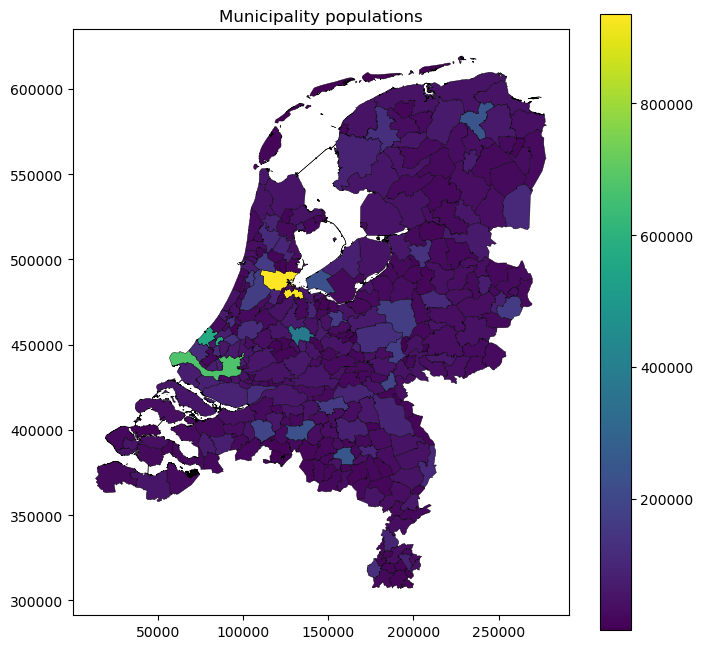

In [22]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8,8))
gementeen.plot(
    column="aantal_inwoners",
    cmap="viridis",
    legend=True,
    edgecolor="black",
    linewidth=0.3,
    ax=ax
) #Look at that its NL

plt.title("Municipality populations")

In [13]:
number_of_na = gementeen.isna().sum().sum() #We have a total of 2604 na
print(f"{round((number_of_na / (gementeen.shape[0] * gementeen.shape[1])) * 100, 2)}% of cells are NA")

#We see that 16.29 of cells are NA

16.29% of cells are NA


### Wijken

data again from 2025 and from 3505. Indicator columns seem to be the same.

In [23]:
wijken = gpd.read_file(DATA_LOC + "GENERAL SOURCES/WijkBuurtkaart_2025_v1/wijkenbuurten_2025_v1.gpkg", layer="wijken")
print(wijken.shape)
print(wijken["jaar"].unique())

wijken= wijken.replace([-99999, -99998, -99997, -99996], np.nan) #Replacing weird numbers with NA
wijken.tail()

(3505, 40)
<StringArray>
['2025']
Length: 1, dtype: str


,wijkcode,wijknaam,gemeentecode,gemeentenaam,indelingswijziging_wijken_en_buurten,water,omgevingsadressendichtheid,stedelijkheid_adressen_per_km2,bevolkingsdichtheid_inwoners_per_km2,aantal_inwoners,...,perc_geb_in_nl_met_herkomstland_in_europa_ex_nl,perc_geb_in_nl_met_herkomstland_buiten_europa,perc_geb_buiten_nl_met_herkomstlnd_in_europa_ex_nl,perc_geb_buiten_nl_met_herkomstlnd_buiten_europa,oppervlakte_totaal_in_ha,oppervlakte_land_in_ha,oppervlakte_water_in_ha,jrstatcode,jaar,geometry
3500,WK199221,Oostvoorne,GM1992,Voorne aan Zee,1.0,NEE,685.0,4.0,357.0,8510.0,...,5.0,5.0,5.0,5.0,2853.0,2380.0,472.0,2025WK199221,2025,"MULTIPOLYGON (((68238.25 434431.688, 68229.703..."
3501,WK199230,Brielle,GM1992,Voorne aan Zee,1.0,NEE,1118.0,3.0,1825.0,14150.0,...,5.0,5.0,5.0,5.0,891.0,775.0,116.0,2025WK199230,2025,"MULTIPOLYGON (((70895.977 435102.906, 71005.77..."
3502,WK199231,Vierpolders,GM1992,Voorne aan Zee,1.0,NEE,257.0,5.0,186.0,1845.0,...,5.0,5.0,5.0,5.0,1037.0,992.0,46.0,2025WK199231,2025,"MULTIPOLYGON (((71778.789 434238.188, 71829.65..."
3503,WK199232,Zwartewaal,GM1992,Voorne aan Zee,1.0,NEE,246.0,5.0,218.0,1890.0,...,5.0,5.0,5.0,5.0,952.0,867.0,85.0,2025WK199232,2025,"MULTIPOLYGON (((74953.203 433877.094, 75068.92..."
3504,WK199233,Recreatiestrook Brielse Maas,GM1992,Voorne aan Zee,1.0,NEE,94.0,5.0,70.0,85.0,...,NaN,0.0,60.0,0.0,233.0,121.0,112.0,2025WK199233,2025,"MULTIPOLYGON (((71464.197 437369.08, 71495.108..."


Text(0.5, 1.0, 'District populations')

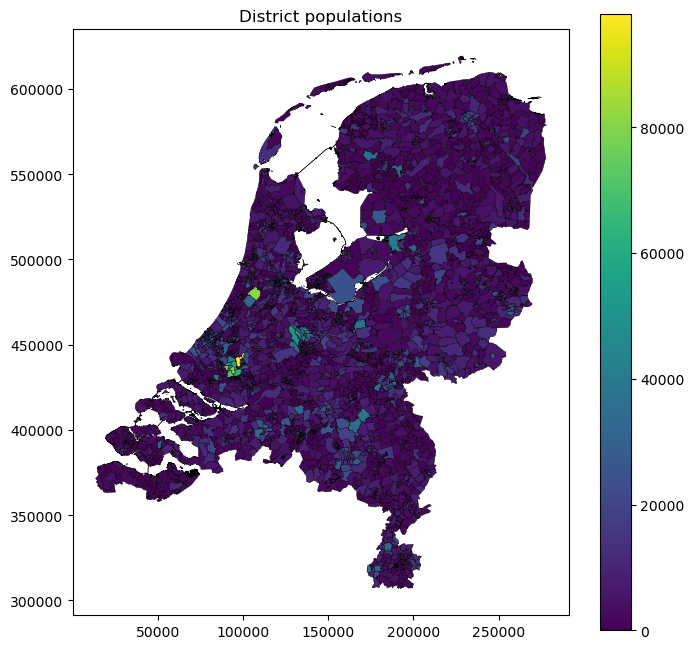

In [25]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8,8))
wijken.plot(
    column="aantal_inwoners",
    cmap="viridis",
    legend=True,
    edgecolor="black",
    linewidth=0.3,
    ax=ax
) #Look at that its NL

plt.title("District populations")

In [28]:
number_of_na = wijken.isna().sum().sum()  #We have a total only 3.41% of na, way less
print(f"{round((number_of_na / (wijken.shape[0] * wijken.shape[1])) * 100, 2)}% of cells are NA")


3.41% of cells are NA


### Buurten

Data from 2025, and 14 823 neighbourhoods.

In [29]:
buurten = gpd.read_file(DATA_LOC + "GENERAL SOURCES/WijkBuurtkaart_2025_v1/wijkenbuurten_2025_v1.gpkg", layer="buurten")
print(buurten.shape)
print(buurten["jaar"].unique())

buurten= buurten.replace([-99999, -99998, -99997, -99996], np.nan) #Replacing weird numbers with NA
buurten.tail()

(14823, 43)
<StringArray>
['2025']
Length: 1, dtype: str


,buurtcode,buurtnaam,wijkcode,gemeentecode,gemeentenaam,indelingswijziging_wijken_en_buurten,water,meest_voorkomende_postcode,dekkingspercentage,omgevingsadressendichtheid,...,perc_geb_in_nl_met_herkomstland_in_europa_ex_nl,perc_geb_in_nl_met_herkomstland_buiten_europa,perc_geb_buiten_nl_met_herkomstlnd_in_europa_ex_nl,perc_geb_buiten_nl_met_herkomstlnd_buiten_europa,oppervlakte_totaal_in_ha,oppervlakte_land_in_ha,oppervlakte_water_in_ha,jrstatcode,jaar,geometry
14818,BU19923200,Zwartewaal,WK199232,GM1992,Voorne aan Zee,1.0,NEE,3238,1.0,282.0,...,5.0,5.0,0.0,5.0,21.0,20.0,0.0,2025BU19923200,2025,"MULTIPOLYGON (((74922.314 433524.127, 74949.75..."
14819,BU19923201,Tuindorp-Hofstede,WK199232,GM1992,Voorne aan Zee,1.0,NEE,3238,3.0,298.0,...,5.0,5.0,0.0,5.0,30.0,27.0,4.0,2025BU19923201,2025,"MULTIPOLYGON (((74742.273 434058.313, 74906.59..."
14820,BU19923202,Zalmlaan,WK199232,GM1992,Voorne aan Zee,1.0,NEE,3238,1.0,299.0,...,0.0,NaN,NaN,NaN,17.0,11.0,6.0,2025BU19923202,2025,"MULTIPOLYGON (((75068.922 433772.594, 75263.40..."
14821,BU19923209,Verspreide huizen,WK199232,GM1992,Voorne aan Zee,1.0,NEE,3238,1.0,110.0,...,0.0,5.0,5.0,5.0,884.0,809.0,75.0,2025BU19923209,2025,"MULTIPOLYGON (((74020.312 434806.313, 74137.25..."
14822,BU19923300,Recreatiestrook Brielse Maas,WK199233,GM1992,Voorne aan Zee,1.0,NEE,3231,1.0,94.0,...,NaN,0.0,60.0,0.0,233.0,121.0,112.0,2025BU19923300,2025,"MULTIPOLYGON (((71464.197 437369.08, 71495.108..."


Text(0.5, 1.0, 'District populations')

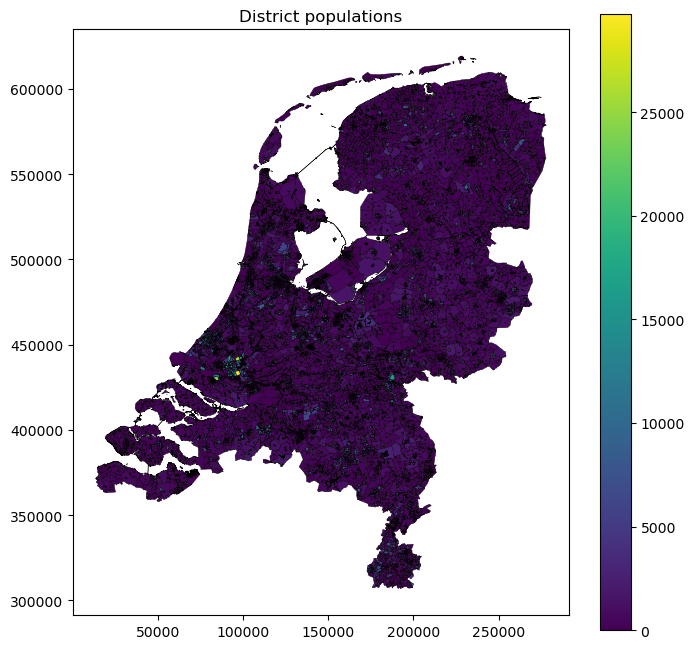

In [30]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8,8))
buurten.plot(
    column="aantal_inwoners",
    cmap="viridis",
    legend=True,
    edgecolor="black",
    linewidth=0.3,
    ax=ax
) #Look at that its NL

plt.title("District populations")

In [31]:
number_of_na = buurten.isna().sum().sum()  #We have a total only 5.86% of na, way less
print(f"{round((number_of_na / (buurten.shape[0] * buurten.shape[1])) * 100, 2)}% of cells are NA")

5.86% of cells are NA


### Summary (sort of)


- Seems like we have a lot of useful indicators available on 3 levels. The municipality level has the most NAs, we might consider incleading previous years and see if that helps with this issue.
- We need to explore indicators more throroughly but I think we should be able to connect them well to problem areas.
- This data also means we have access to municipality, neighbourhood and district polygons. The polygons are likely to be useful in the future, both for merging data, visualizing them, as well as setting up areas under study and baselines.
- Overall this data seems like a great fit and start